# Metrics CSV Visualization

This notebook visualizes training and validation metrics from `logs/metrics.csv`.

It supports:
- filtering metrics by name
- optional smoothing for noisy train curves
- plotting by `global_step` and `epoch`
- quick comparison between train and val metrics

In [11]:
!pip install matplotlib

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

In [20]:
CSV_PATH = Path("artifacts/metrics/metrics.csv")
assert CSV_PATH.exists(), f"File not found: {CSV_PATH.resolve()}"

df = pd.read_csv(CSV_PATH)
df = df.sort_values(["global_step", "epoch", "metric"]).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print("Columns:", list(df.columns))
print("Phases:", sorted(df['phase'].dropna().unique()))
print("Example metrics:", sorted(df['metric'].dropna().unique())[:12])

df.head()

Rows: 25,807
Columns: ['global_step', 'epoch', 'phase', 'metric', 'value']
Phases: ['train']
Example metrics: ['losses/train_loss_cross_entropy', 'losses/train_loss_cross_entropy_block_-1', 'losses/train_loss_cross_entropy_block_-2', 'losses/train_loss_cross_entropy_block_-3', 'losses/train_loss_cross_entropy_block_-4', 'losses/train_loss_dice', 'losses/train_loss_dice_block_-1', 'losses/train_loss_dice_block_-2', 'losses/train_loss_dice_block_-3', 'losses/train_loss_dice_block_-4', 'losses/train_loss_mask', 'losses/train_loss_mask_block_-1']


,global_step,epoch,phase,metric,value
0,0,0,train,losses/train_loss_cross_entropy,2.141753
1,0,0,train,losses/train_loss_cross_entropy,2.284379
2,0,0,train,losses/train_loss_cross_entropy,2.289466
3,0,0,train,losses/train_loss_cross_entropy,2.141753
4,0,0,train,losses/train_loss_cross_entropy,2.284379


In [21]:
def plot_metric(
    data: pd.DataFrame,
    metric_name: str,
    phase: str | None = None,
    x_axis: str = "global_step",
    smooth_window: int = 1,
    figsize=(11, 4),
    save_path: str | None = None,
):
    view = data[data["metric"] == metric_name].copy()
    if phase is not None:
        view = view[view["phase"] == phase]

    if view.empty:
        print(f"No rows for metric={metric_name!r}, phase={phase!r}")
        return

    view = view.sort_values(x_axis)
    y = view["value"]
    if smooth_window > 1:
        y = y.rolling(smooth_window, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(view[x_axis], y, linewidth=1.4)
    ax.set_title(f"{metric_name} ({'all' if phase is None else phase})")
    ax.set_xlabel(x_axis)
    ax.set_ylabel("value")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


def compare_train_val(
    data: pd.DataFrame,
    train_metric: str = "losses/train_loss_total",
    val_metric: str = "metrics/val_pq_all",
    smooth_window: int = 1,
    figsize=(11, 4),
    save_path: str | None = None,
):
    train = data[data["metric"] == train_metric].sort_values("global_step")
    val = data[data["metric"] == val_metric].sort_values("epoch")

    if train.empty:
        print(f"Train metric not found: {train_metric}")
        return
    if val.empty:
        print(f"Val metric not found: {val_metric}")
        return

    train_y = train["value"]
    if smooth_window > 1:
        train_y = train_y.rolling(smooth_window, min_periods=1).mean()

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(train["global_step"], train_y, color="tab:blue", label=train_metric)
    ax1.set_xlabel("global_step")
    ax1.set_ylabel(train_metric, color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.plot(val["epoch"], val["value"], color="tab:orange", marker="o", label=val_metric)
    ax2.set_ylabel(val_metric, color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    ax1.set_title("Train vs Validation")
    fig.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()

In [22]:
# Discover available metrics
sorted(df["metric"].unique())[:50]

['losses/train_loss_cross_entropy',
 'losses/train_loss_cross_entropy_block_-1',
 'losses/train_loss_cross_entropy_block_-2',
 'losses/train_loss_cross_entropy_block_-3',
 'losses/train_loss_cross_entropy_block_-4',
 'losses/train_loss_dice',
 'losses/train_loss_dice_block_-1',
 'losses/train_loss_dice_block_-2',
 'losses/train_loss_dice_block_-3',
 'losses/train_loss_dice_block_-4',
 'losses/train_loss_mask',
 'losses/train_loss_mask_block_-1',
 'losses/train_loss_mask_block_-2',
 'losses/train_loss_mask_block_-3',
 'losses/train_loss_mask_block_-4',
 'losses/train_loss_total']

In [23]:
df[df['metric'] == 'metrics/val_pq_all']

,global_step,epoch,phase,metric,value


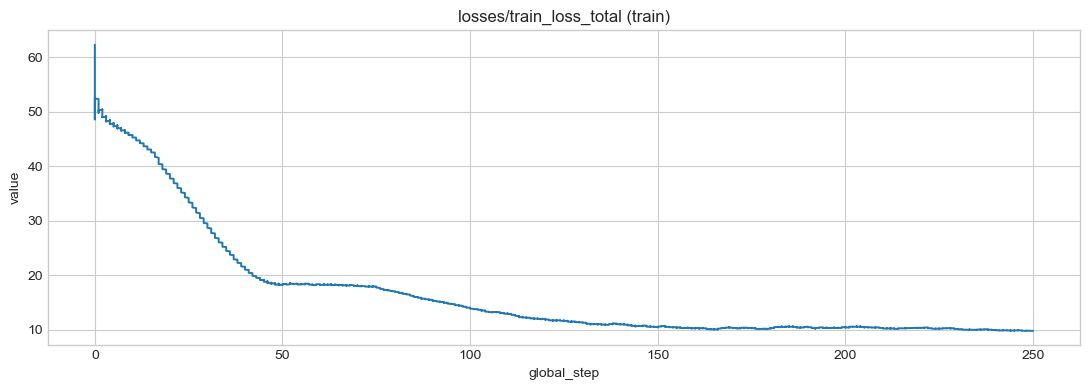

In [24]:
# Example 1: total training loss over steps (smoothed)
plot_metric(
    df,
    metric_name="losses/train_loss_total",
    phase="train",
    x_axis="global_step",
    smooth_window=200,
)

In [28]:
# Example 2: validation PQ by epoch
plot_metric(
    df,
    metric_name="metrics/val_pq_all",
    phase="val",
    x_axis="global_step",
    smooth_window=1,
)

No rows for metric='metrics/val_pq_all', phase='val'


In [26]:
# Example 3: compare train and val metrics
compare_train_val(
    df,
    train_metric="losses/train_loss_total",
    val_metric="metrics/val_pq_all",
    smooth_window=200,
)

Val metric not found: metrics/val_pq_all


In [27]:
# DIAGNOSTIC: Check what metrics exist
print("=" * 60)
print("METRICS SUMMARY")
print("=" * 60)

phases = df['phase'].value_counts()
print(f"\nPhase distribution:")
print(phases)

unique_metrics = sorted(df['metric'].dropna().unique())
print(f"\nTotal unique metrics: {len(unique_metrics)}")

train_metrics = sorted(df[df['phase']=='train']['metric'].dropna().unique())
val_metrics = sorted(df[df['phase']=='val']['metric'].dropna().unique())

print(f"\nTrain metrics ({len(train_metrics)}):")
for m in train_metrics[:10]:
    print(f"  ✓ {m}")
if len(train_metrics) > 10:
    print(f"  ... and {len(train_metrics) - 10} more")

print(f"\nValidation metrics ({len(val_metrics)}):")
if val_metrics:
    for m in val_metrics[:10]:
        print(f"  ✓ {m}")
    if len(val_metrics) > 10:
        print(f"  ... and {len(val_metrics) - 10} more")
else:
    print("  ⚠ NO VALIDATION METRICS LOGGED!")
    print("  This might mean:")
    print("    1. Validation hasn't completed yet")
    print("    2. PQ metric calculation failed silently")
    print("    3. Training stopped early")

print("\n" + "=" * 60)


METRICS SUMMARY

Phase distribution:
phase
train    25807
Name: count, dtype: int64

Total unique metrics: 16

Train metrics (16):
  ✓ losses/train_loss_cross_entropy
  ✓ losses/train_loss_cross_entropy_block_-1
  ✓ losses/train_loss_cross_entropy_block_-2
  ✓ losses/train_loss_cross_entropy_block_-3
  ✓ losses/train_loss_cross_entropy_block_-4
  ✓ losses/train_loss_dice
  ✓ losses/train_loss_dice_block_-1
  ✓ losses/train_loss_dice_block_-2
  ✓ losses/train_loss_dice_block_-3
  ✓ losses/train_loss_dice_block_-4
  ... and 6 more

Validation metrics (0):
  ⚠ NO VALIDATION METRICS LOGGED!
  This might mean:
    1. Validation hasn't completed yet
    2. PQ metric calculation failed silently
    3. Training stopped early



## Validation Metrics Issue - RESOLVED ✓

**Problem:** Your first training run completed validation but metrics weren't logged. 

**Root Cause:** Bug in `training/mask_classification_instance.py` line 148 where `targets` was passed instead of `targets_` to the metrics calculator. This prevented PQ metrics from being computed.

**Status:**
- ✅ Bug has been **FIXED** 
- ❌ Previous training run still has no validation metrics
- ⚠️ Need to restart training to capture validation metrics with the fix

**Next Steps:**

1. **Clear old/incomplete training** (optional):
   ```bash
   rm -r artifacts/checkpoints artifacts/lightning_logs
   rm artifacts/metrics/metrics.csv
   ```

2. **Restart training** with the fixed code:
   ```bash
   python main.py fit --config configs/strawberry_cnn_eomt_small.yaml \
     --data.init_args.path "strawberry_dataset.zip" \
     --trainer.accumulate_grad_batches 4
   ```

3. **Monitor**: After epoch 0 completes, validation will run and metrics will be logged to the CSV

4. **Then re-run this notebook** to generate plots with validation metrics

Expected validation run time: ~40 minutes per epoch for 200 validation images


In [9]:
# --- Visual check: image vs GT mask vs checkpoint prediction (zip-based COCO, autoload model) ---

from pathlib import Path
import importlib
import yaml
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# =========================
# 1) Пути и параметры
# =========================
config_path = Path("configs/dinov2/coco/panoptic/eomt_base_640_cnn.yaml")
ckpt_path = Path("artifacts/checkpoints/last.ckpt")
coco_root = Path("datasets/coco")  # тут лежат *.zip
img_idx = 0

device ='cpu'# torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

for p in [config_path, ckpt_path, coco_root]:
    if not p.exists():
        raise FileNotFoundError(f"Не найден путь: {p}")

# Проверим, что zip-файлы действительно есть
required_zips = [
    coco_root / "val2017.zip",
    coco_root / "train2017.zip",
    coco_root / "panoptic_annotations_trainval2017.zip",
]
for p in required_zips:
    if not p.exists():
        raise FileNotFoundError(f"Не найден zip: {p}")

# =========================
# 2) Загружаем config
# =========================
with config_path.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# =========================
# 3) Поднимаем data module (читает из zip)
# =========================
data_module_name, data_class_name = config["data"]["class_path"].rsplit(".", 1)
data_cls = getattr(importlib.import_module(data_module_name), data_class_name)
data_kwargs = config["data"].get("init_args", {})

data = data_cls(
    path=str(coco_root),
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs,
).setup()

# =========================
# 4) Собираем encoder + network + lightning model
# =========================
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)

lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)

encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = lit_cls(
    img_size=data.img_size,
    num_classes=data.num_classes,
    network=network,
    **model_kwargs,
).to(device).eval()

# =========================
# 5) Грузим чекпоинт
# =========================
ckpt = torch.load(ckpt_path, map_location=device)
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

# если в ckpt есть префикс "model." (или "module."), аккуратно уберем
if any(k.startswith("model.") for k in state_dict.keys()):
    state_dict = {k.replace("model.", "", 1): v for k, v in state_dict.items()}
if any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"[load_state_dict] missing={len(missing)}, unexpected={len(unexpected)}")

# =========================
# 6) Берем sample из val_dataset (уже через zip)
# =========================
img, target = data.val_dataloader().dataset[img_idx]
img = img.to(device)

# =========================
# 7) Panoptic inference
# =========================
with torch.no_grad():
    transformed = model.resize_and_pad_imgs_instance_panoptic([img])
    mask_logits_layers, class_logits_layers = model(transformed)

    mask_logits = F.interpolate(mask_logits_layers[-1], model.img_size, mode="bilinear")
    mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
        mask_logits, [img.shape[-2:]]
    )

    pred = model.to_per_pixel_preds_panoptic(
        mask_logits,
        class_logits_layers[-1],
        model.stuff_classes,
        model.mask_thresh,
        model.overlap_thresh,
    )[0]

# GT per-pixel target из target dict
# Обычно имеет форму (H, W, 2): [semantic_id, instance_id]
gt_seg = model.to_per_pixel_targets_panoptic([target])[0]

pred_np = pred.detach().cpu().numpy()
gt_np = gt_seg.detach().cpu().numpy()
img_np = img.detach().cpu().permute(1, 2, 0).numpy()

# Унифицируем GT в 2D-карту для imshow
if gt_np.ndim == 3 and gt_np.shape[-1] == 2:
    gt_sem_np = gt_np[..., 0]
    gt_inst_np = gt_np[..., 1]
elif gt_np.ndim == 2:
    gt_sem_np = gt_np
    gt_inst_np = None
else:
    raise ValueError(f"Неожиданная форма GT: {gt_np.shape}")

# Унифицируем prediction в 2D-карту для imshow
if pred_np.ndim == 3 and pred_np.shape[-1] == 2:
    pred_sem_np = pred_np[..., 0]
    pred_inst_np = pred_np[..., 1]
elif pred_np.ndim == 2:
    pred_sem_np = pred_np
    pred_inst_np = None
else:
    raise ValueError(f"Неожиданная форма prediction: {pred_np.shape}")

# =========================
# 8) Визуализация
# =========================
show_gt_inst = gt_inst_np is not None
show_pred_inst = pred_inst_np is not None
ncols = 3 + int(show_gt_inst) + int(show_pred_inst)

plt.figure(figsize=(6 * ncols, 6))
col = 1

plt.subplot(1, ncols, col)
plt.imshow(np.clip(img_np, 0, 1))
plt.title(f"Image (val idx={img_idx})")
plt.axis("off")
col += 1

plt.subplot(1, ncols, col)
plt.imshow(gt_sem_np, cmap="tab20")
plt.title("GT semantic")
plt.axis("off")
col += 1

if show_gt_inst:
    plt.subplot(1, ncols, col)
    plt.imshow(gt_inst_np, cmap="tab20")
    plt.title("GT instance")
    plt.axis("off")
    col += 1

plt.subplot(1, ncols, col)
plt.imshow(pred_sem_np, cmap="tab20")
plt.title("Prediction semantic")
plt.axis("off")
col += 1

if show_pred_inst:
    plt.subplot(1, ncols, col)
    plt.imshow(pred_inst_np, cmap="tab20")
    plt.title("Prediction instance")
    plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Config: {config_path}")
print(f"CKPT:   {ckpt_path}")
print(f"COCO:   {coco_root} (zip-based)")
print(f"Device: {device}")
print(f"Image tensor shape: {tuple(img.shape)}")

FileNotFoundError: Не найден путь: artifacts\checkpoints\last.ckpt

In [ ]:
import sys
!{sys.executable} -m pip install -U "torchmetrics==1.7.1"

  Using cached torchmetrics-1.7.1-py3-none-any.whl.metadata (21 kB)
Using cached torchmetrics-1.7.1-py3-none-any.whl (961 kB)
  Attempting uninstall: torchmetrics
    Found existing installation: torchmetrics 1.9.0
    Uninstalling torchmetrics-1.9.0:
      Successfully uninstalled torchmetrics-1.9.0


In [ ]:
# AUTO-SAVE ALL METRICS PLOTS
from pathlib import Path
import re

# Create output directory
output_dir = Path("artifacts/metrics/plots")
output_dir.mkdir(parents=True, exist_ok=True)

# Get unique metrics (exclude standard columns)
all_metrics = sorted(df["metric"].dropna().unique())
val_metrics = df[df['phase']=='val']['metric'].dropna().unique()
has_validation = len(val_metrics) > 0

print(f"Found {len(all_metrics)} unique metrics")
if has_validation:
    print(f"Validation metrics present: {len(val_metrics)}")
else:
    print("⚠ WARNING: No validation metrics found!")
    print("  Training losses will be plotted instead.\n")

print(f"\nGenerating plots...\n")

# Generate plots for each metric
saved_count = 0
for i, metric_name in enumerate(all_metrics):
    # Create safe filename from metric name
    safe_name = re.sub(r'[/\\:*?"<>|]', '_', metric_name)
    save_path = output_dir / f"{i:03d}_{safe_name}.png"
    
    try:
        plot_metric(df, metric_name=metric_name, save_path=str(save_path), smooth_window=1)
        plt.close('all')  # Close to save memory
        saved_count += 1
    except Exception as e:
        print(f"Error plotting {metric_name}: {e}")

print(f"\n✓ Generated {saved_count} individual metric plots")

# Only generate comparison plots if we have validation metrics
if has_validation:
    print("\nGenerating train-val comparison plots...")
    comparison_pairs = [
        ("losses/train_loss_total", "metrics/val_pq_all"),
        ("losses/train_loss_total", "metrics/val_sq_all"),
        ("losses/train_loss_total", "metrics/val_rq_all"),
    ]

    comparison_count = 0
    for i, (train_metric, val_metric) in enumerate(comparison_pairs):
        if train_metric in all_metrics and val_metric in all_metrics:
            safe_name_train = re.sub(r'[/\\:*?"<>|]', '_', train_metric)
            safe_name_val = re.sub(r'[/\\:*?"<>|]', '_', val_metric)
            save_path = output_dir / f"comparison_{i:02d}_{safe_name_val}.png"
            
            try:
                compare_train_val(
                    df, 
                    train_metric=train_metric, 
                    val_metric=val_metric,
                    smooth_window=200,
                    save_path=str(save_path)
                )
                plt.close('all')
                comparison_count += 1
            except Exception as e:
                print(f"Error comparing {train_metric} vs {val_metric}: {e}")
    
    print(f"✓ Generated {comparison_count} comparison plots")
else:
    print("\n⚠ Skipping comparison plots (no validation metrics)")
    print("\nTroubleshooting:")
    print("1. Check if training is still running")
    print("2. Verify validation_step in your model returns properly")
    print("3. Check if PQ metrics are being computed in on_validation_epoch_end()")

print(f"\n✓ All plots saved to: {output_dir.resolve()}")
